# Style and Sector ETF Rotation with bt

ETF rotation is a natural target-weight problem. This notebook constructs De-Time rotation weights and shows how they can be passed to the `bt` framework.

**Default decomposition:** `ROBUST_STL` with a 63-trading-day period, computed walk-forward where signals are backtested.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from examples.quant_trading.data import fetch_yahoo_prices, fetch_yahoo_ohlcv, data_audit_report, DEFAULT_UNIVERSES
from examples.quant_trading.features import decompose_one_series, walkforward_decompose, build_feature_table
from examples.quant_trading.signals import (
    trend_pullback_signals,
    residual_mean_reversion_signals,
    turtle_donchian_signals,
    pair_trading_weights,
    cross_sectional_rotation_weights,
    residual_stress_filter,
)
from examples.quant_trading.backtest import backtest_weights, backtest_long_short_signals, summarize_returns

DATA_CACHE = Path("examples/quant_trading/data/cache")
QUANT_METHOD = "ROBUST_STL"
QUANT_PERIOD = 63


In [2]:
universe = DEFAULT_UNIVERSES["us_sector_etfs"]
prices = fetch_yahoo_prices(universe, start="2016-01-01", cache_dir=DATA_CACHE)
features = walkforward_decompose(prices, method=QUANT_METHOD, period=QUANT_PERIOD, train_window=252, step=21)
weights = cross_sectional_rotation_weights(prices, features, top_n=3, vol_target=0.12, max_weight=0.40)
result = backtest_weights(prices, weights, fee_bps=1.0, slippage_bps=2.0)
result.stats_frame()

,value
total_return,1.801815
cagr,0.104506
volatility,0.125549
sharpe,0.854848
max_drawdown,-0.204708
calmar,0.510511
hit_rate,0.493109
average_turnover,0.066460
average_gross_exposure,0.863424
fee_bps,1.000000


In [3]:
weights.tail().style.format("{:.2%}")

,XLK,XLF,XLE,XLV,XLY,XLP,XLI,XLU,XLB,XLRE,XLC
Date,,,,,,,,,,,
2026-05-18 00:00:00,0.00%,0.00%,31.90%,0.00%,0.00%,0.00%,0.00%,0.00%,31.90%,31.90%,0.00%
2026-05-19 00:00:00,0.00%,0.00%,32.03%,0.00%,0.00%,0.00%,0.00%,0.00%,32.03%,32.03%,0.00%
2026-05-20 00:00:00,0.00%,0.00%,32.58%,0.00%,0.00%,0.00%,0.00%,0.00%,32.58%,32.58%,0.00%
2026-05-21 00:00:00,0.00%,0.00%,32.58%,0.00%,0.00%,0.00%,0.00%,0.00%,32.58%,32.58%,0.00%
2026-05-22 00:00:00,0.00%,0.00%,32.63%,0.00%,0.00%,0.00%,0.00%,0.00%,32.63%,32.63%,0.00%


## Decomposition-to-weight bridge

Sector rotation uses the same decomposition score as the cross-sectional notebook: trend rank, residual pullback rank, cycle slope rank, and a small reconstruction-error penalty. The table makes the latest allocation traceable to those ingredients.

In [4]:
score_date = weights.abs().sum(axis=1).replace(0.0, np.nan).dropna().index[-1]
trend_rank = features["trend_slope"].loc[score_date].rank(pct=True)
pullback_rank = (-features["residual_z"].loc[score_date]).rank(pct=True)
cycle_rank = features["season_slope"].loc[score_date].rank(pct=True)
noise_penalty = features["reconstruction_error"].loc[score_date].rank(pct=True)
sector_score_parts = pd.DataFrame({
    "trend_rank": trend_rank,
    "residual_pullback_rank": pullback_rank,
    "cycle_rank": cycle_rank,
    "reconstruction_penalty": noise_penalty,
})
sector_score_parts["final_score"] = sector_score_parts["trend_rank"] + sector_score_parts["residual_pullback_rank"] + sector_score_parts["cycle_rank"] - 0.25 * sector_score_parts["reconstruction_penalty"]
sector_score_parts["target_weight"] = weights.loc[score_date]
sector_score_parts.sort_values("final_score", ascending=False).style.format("{:.3f}")

,trend_rank,residual_pullback_rank,cycle_rank,reconstruction_penalty,final_score,target_weight
XLB,0.909,0.636,0.818,0.545,2.227,0.326
XLE,1.000,0.364,0.909,0.545,2.136,0.326
XLRE,0.545,0.909,0.636,0.545,1.955,0.326
XLK,0.455,0.455,1.000,0.545,1.773,0.000
XLV,0.364,0.727,0.727,0.545,1.682,0.000
XLI,0.727,0.545,0.364,0.545,1.500,0.000
XLC,0.273,1.000,0.182,0.545,1.318,0.000
XLP,0.636,0.273,0.545,0.545,1.318,0.000
XLF,0.091,0.818,0.455,0.545,1.227,0.000
XLU,0.818,0.182,0.273,0.545,1.136,0.000


## Visualization: selected sector decomposition and allocation

This panel checks the sector that currently receives the largest weight. If its target weight is driven by a noisy residual spike rather than a stable trend/cycle setup, the rotation rule should be tightened before deployment.

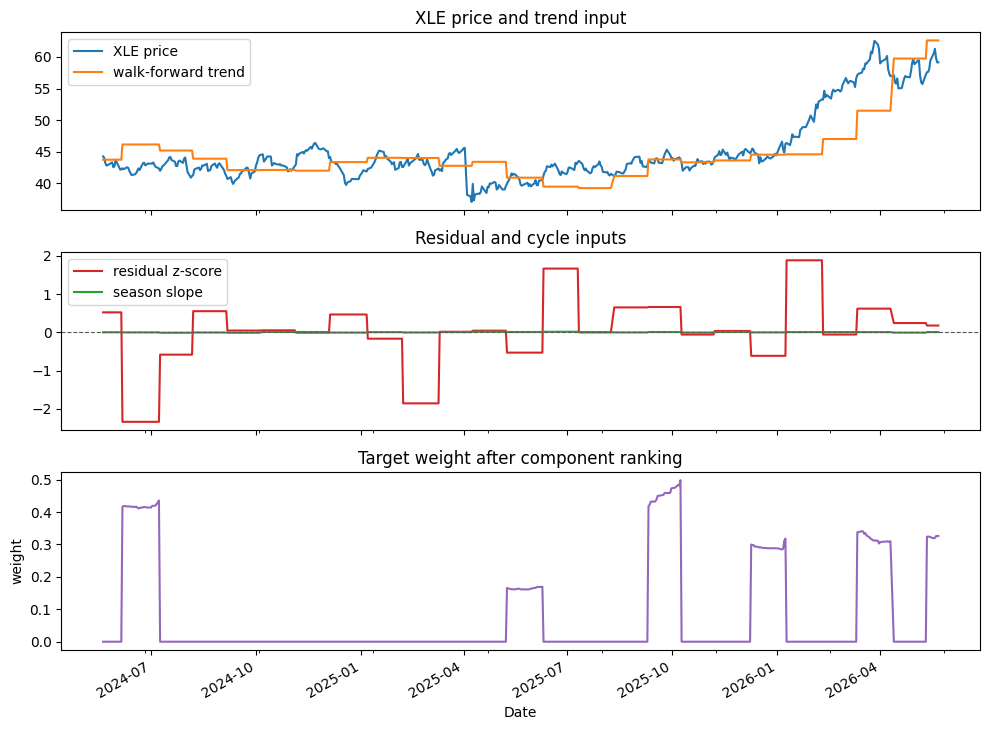

In [5]:
selected_sector = sector_score_parts["target_weight"].idxmax() if sector_score_parts["target_weight"].max() > 0 else sector_score_parts["final_score"].idxmax()
window = prices.index[-504:]
trend_level = np.exp(features["trend"][selected_sector]).reindex(window)
residual_z = features["residual_z"][selected_sector].reindex(window)
season_slope = features["season_slope"][selected_sector].reindex(window)
sector_weight = weights[selected_sector].reindex(window)

fig, axes = plt.subplots(3, 1, figsize=(10, 7.4), sharex=True)
prices[selected_sector].reindex(window).plot(ax=axes[0], color="tab:blue", label=f"{selected_sector} price")
trend_level.plot(ax=axes[0], color="tab:orange", label="walk-forward trend")
axes[0].set_title(f"{selected_sector} price and trend input")
axes[0].legend(loc="best")
residual_z.plot(ax=axes[1], color="tab:red", label="residual z-score")
season_slope.plot(ax=axes[1], color="tab:green", label="season slope")
axes[1].axhline(0.0, color="0.35", linestyle="--", linewidth=0.8)
axes[1].set_title("Residual and cycle inputs")
axes[1].legend(loc="best")
sector_weight.plot(ax=axes[2], color="tab:purple", title="Target weight after component ranking")
axes[2].set_ylabel("weight")
plt.tight_layout()
plt.show()

## Visualization: sector rotation diagnostics

Equity, allocation, and gross exposure are shown together for the sector-rotation variant.

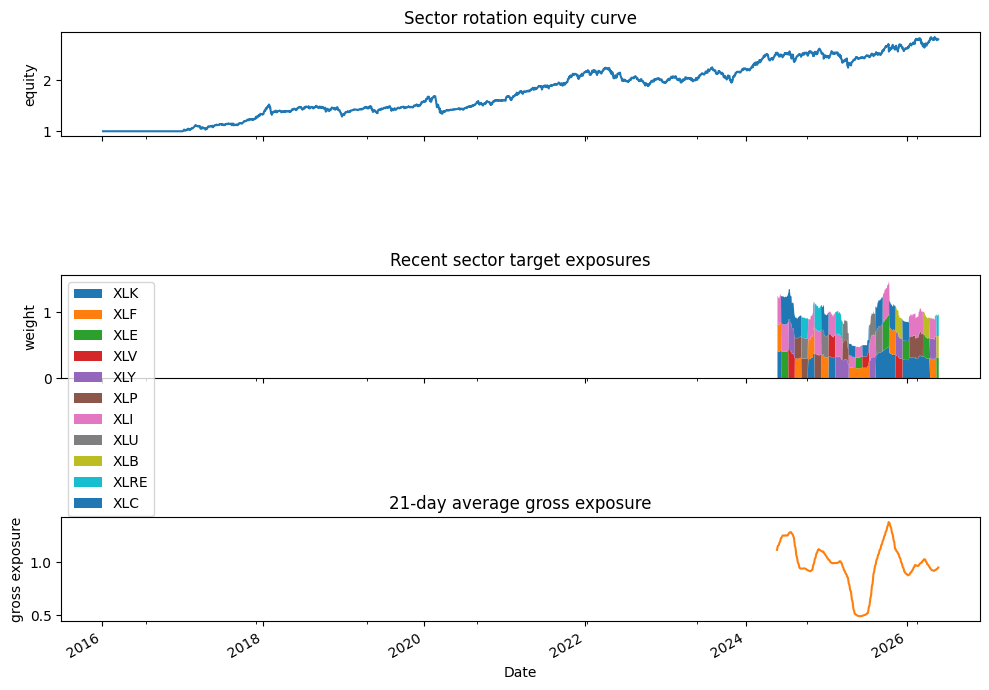

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
result.equity.plot(ax=axes[0], title="Sector rotation equity curve")
weights.tail(504).plot.area(ax=axes[1], title="Recent sector target exposures", linewidth=0.0)
weights.abs().sum(axis=1).rolling(21, min_periods=1).mean().tail(504).plot(ax=axes[2], color="tab:orange", title="21-day average gross exposure")
axes[0].set_ylabel("equity")
axes[1].set_ylabel("weight")
axes[2].set_ylabel("gross exposure")
plt.tight_layout()
plt.show()


## Optional: bt adapter

In [7]:
from examples.quant_trading.frameworks import run_bt_target_weights

# bt_result = run_bt_target_weights(prices, weights, name="detime_sector_rotation")
# bt_result.display()